In [ ]:
# ============================
# Cell 0: USER SETTINGS
# ============================
# Purpose:
# - Define which runs to compare (MDEG values)
# - Choose fiducial/reference MDEG (we'll compare everything to this)
# - Define analysis wavelength range (IMPORTANT: include SIII 9069 -> go past 9100)
# - Define line-free windows (for baseline & noise_level)
# - Define emission-line windows + sidebands (for baseline-subtracted flux)
#
# Notes:
# - "line_cube" is continuum-subtracted, so in line-free windows it should be ~0 baseline.
# - We'll call the within-window scatter "noise_level" (robust MAD sigma), not "sky_rms".

from pathlib import Path

# Your run folders in pwd (edit names if needed)
run_ids = {
    8:  "IC3392_v3tk_9100_mask_uptoCONT_MDEG8",
    12: "IC3392_v3tk_9100_mask_uptoCONT_MDEG12",
    14: "IC3392_v3tk_9100_mask_uptoCONT_MDEG14",
    16: "IC3392_v3tk_9100_mask_uptoCONT_MDEG16",
    20: "IC3392_v3tk_9100_mask_uptoCONT_MDEG20",
}
REF_MDEG = 14  # fiducial reference for stability tests

# Wavelength range for analysis (include [S III] 9069)
WMIN, WMAX = 4800.0, 9100.0

# --- Line-free-ish windows for baseline + drift + noise_level diagnostics
# Try to avoid strong nebular lines; these are "check" bands not perfect sky-only bands.
linefree_windows = {
    "cont_5050_5120": (5050.0, 5120.0),
    "cont_5218_5485": (5218.0, 5485.0),
    "cont_5600_5650": (5600.0, 5650.0),
    "cont_6000_6200": (6000.0, 6200.0),
    "cont_6400_6500": (6400.0, 6500.0),
    "cont_8200_8250": (8200.0, 8250.0),
    "cont_8800_8850": (8800.0, 8850.0),
}

# --- A few "difficult" red windows to monitor behavior (optional, but useful)
# These are not line-free; they tell you where subtraction is tricky (skylines/CaT region).
red_watch_windows = {
    "ArIII_zone_7085_7185": (7085.0, 7185.0),
    "OII_zone_7285_7355":   (7285.0, 7355.0),
    "CaT_zone_8470_8700":   (8470.0, 8700.0),
    "SIII_zone_9040_9105":  (9040.0, 9105.0),
}

# --- Emission line definitions: each has a line window and two sidebands for baseline subtraction
# We keep windows narrow to reduce blending. You can tune widths if needed.
line_defs = {
    # Balmer + OIII
    "Hb": {
        "line": (4852.0, 4872.0),
        "side": ((4825.0, 4845.0), (4880.0, 4900.0))
    },
    "OIII5007": {
        "line": (5002.0, 5018.0),
        "side": ((4985.0, 4998.0), (5022.0, 5038.0))
    },

    # Separate Hα and [NII] (approximate; tune if you want less blending)
    "Ha": {
        "line": (6557.0, 6569.0),
        "side": ((6525.0, 6542.0), (6578.0, 6592.0))
    },
    "NII6583": {
        "line": (6579.0, 6589.5),
        "side": ((6557.0, 6569.0), (6600.0, 6615.0))
    },

    # [S II] doublet: do separately and sum later
    "SII6716": {
        "line": (6711.0, 6722.0),
        "side": ((6695.0, 6708.0), (6725.0, 6738.0))
    },
    "SII6731": {
        "line": (6726.0, 6737.0),
        "side": ((6711.0, 6722.0), (6740.0, 6755.0))
    },

    # Red lines
    "ArIII7136": {
        "line": (7129.0, 7143.5),
        "side": ((7105.0, 7120.0), (7150.0, 7168.0))
    },
    "OII7325": {  # combined OII 7320/7330-ish
        "line": (7317.0, 7337.0),
        "side": ((7295.0, 7310.0), (7345.0, 7360.0))
    },
    "SIII9069": {
        "line": (9061.0, 9077.5),
        "side": ((9045.0, 9058.0), (9082.0, 9098.0))
    },
}

print("Configured MDEGs:", sorted(run_ids.keys()))
print("Reference MDEG:", REF_MDEG)
print("Analysis range:", (WMIN, WMAX))


Configured MDEGs: [8, 12, 14, 16, 20]
Reference MDEG: 14
Analysis range: (4800.0, 9100.0)


In [3]:
# ============================
# Cell 1: LOAD LINE CUBES + WAVELENGTH GRID
# ============================
# Purpose:
# - Open each MDEG line cube using memmap to avoid loading the full cube into RAM.
# - Build the wavelength array from FITS WCS keywords in the header.
# - Verify wavelength range covers WMIN..WMAX and includes SIII 9069.

import numpy as np
from astropy.io import fits

def build_wave_from_header(hdr, nw):
    # Standard FITS spectral WCS: CRVAL3 + (pix-CRPIX3)*CDELT3
    crval = hdr.get("CRVAL3", None)
    cdelt = hdr.get("CDELT3", hdr.get("CD3_3", None))
    crpix = hdr.get("CRPIX3", 1.0)
    if crval is None or cdelt is None:
        raise ValueError("Missing CRVAL3 and/or CDELT3/CD3_3 in header.")
    pix = np.arange(nw, dtype=float) + 1.0  # FITS is 1-indexed
    return crval + (pix - crpix) * cdelt

# Open HDUs and keep them open (memmap arrays depend on file handle)
hdul_line = {}
line_cube = {}

for mdeg, rid in run_ids.items():
    fp = Path.cwd() / rid / f"{rid}_line_cube.fits"
    if not fp.exists():
        raise FileNotFoundError(f"Missing line cube: {fp}")
    hdul_line[mdeg] = fits.open(fp, memmap=True)
    line_cube[mdeg] = hdul_line[mdeg][0].data  # memmap array (nw, ny, nx)
    print(f"MDEG {mdeg}: {fp.name} shape={line_cube[mdeg].shape}")

# Use REF cube to build wavelength grid
hdr = hdul_line[REF_MDEG][0].header
nw, ny, nx = line_cube[REF_MDEG].shape
wave = build_wave_from_header(hdr, nw)

print("\nWavelength coverage:", wave.min(), "to", wave.max(), "Angstrom")
print("Includes [S III] 9069?", (wave.min() < 9069.0) and (wave.max() > 9069.0))

# Select analysis range (we use this everywhere below)
sel = (wave >= WMIN) & (wave <= WMAX)
wave_sel = wave[sel]
print("Selected analysis range:", wave_sel.min(), "to", wave_sel.max(), "Angstrom")
print("Selected nw:", wave_sel.size)


MDEG 8: IC3392_v3tk_9100_mask_uptoCONT_MDEG8_line_cube.fits shape=(3459, 438, 437)
MDEG 12: IC3392_v3tk_9100_mask_uptoCONT_MDEG12_line_cube.fits shape=(3459, 438, 437)
MDEG 14: IC3392_v3tk_9100_mask_uptoCONT_MDEG14_line_cube.fits shape=(3459, 438, 437)
MDEG 16: IC3392_v3tk_9100_mask_uptoCONT_MDEG16_line_cube.fits shape=(3459, 438, 437)
MDEG 20: IC3392_v3tk_9100_mask_uptoCONT_MDEG20_line_cube.fits shape=(3459, 438, 437)

Wavelength coverage: 4827.5 to 9150.0 Angstrom
Includes [S III] 9069? True
Selected analysis range: 4827.5 to 9100.0 Angstrom
Selected nw: 3419


/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_29328/6966246.py:59: RuntimeWarning: All-NaN slice encountered
  amp_map = np.nanmedian(np.abs(line_cube[REF_MDEG][wm, :, :]), axis=0)


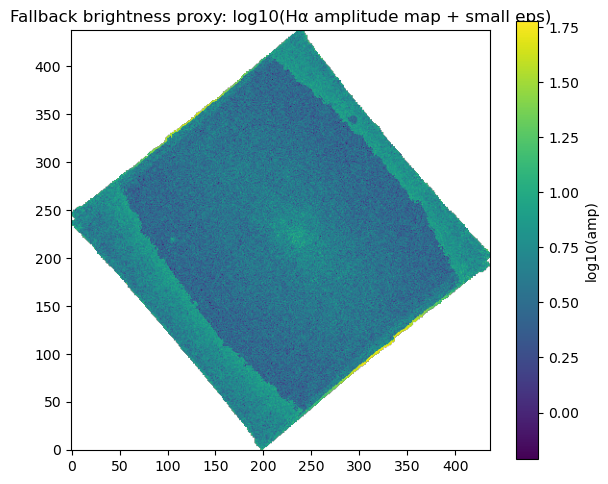

In [4]:
# ============================
# Cell 2: BUILD A CONTINUUM MAP (OPTIONAL) FOR INNER/OUTER MASKING
# ============================
# Purpose:
# - For robustness, we want diagnostics to hold in bright inner galaxy spaxels,
#   not just in faint outskirts.
# - Best way: use ORIG cube to make cont_map (median flux in a continuum window).
# - If you do NOT have ORIG cube path available, we fall back to an Hα amplitude map
#   computed from line cubes (still ok, but less direct).
#
# What are cont_map and floor?
# - cont_map: a 2D map of continuum brightness (median flux in CONT_WIN).
# - floor: a small positive number added so log10(|cont_map| + floor) is well-defined.
#   (plotting trick; not physics)

import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

USE_ORIG = False  # set True if you provide ORIG cube path below

# ---- If you want to use ORIG cube, set these:
ORIG_FP = None     # e.g. Path("IC3392_DATACUBE_FINAL_WCS_...fits")
ORIG_EXT = 0
CONT_WIN = (5218.0, 5485.0)  # continuum window used to define brightness

cont_map = None
cont_floor = None

if USE_ORIG:
    if ORIG_FP is None:
        raise ValueError("Set ORIG_FP to your ORIG datacube path, or set USE_ORIG=False.")
    with fits.open(ORIG_FP, memmap=True) as hd:
        orig = hd[ORIG_EXT].data
        ohdr = hd[ORIG_EXT].header
        owave = build_wave_from_header(ohdr, orig.shape[0])

        m = (owave >= CONT_WIN[0]) & (owave <= CONT_WIN[1])
        # This loads only the wavelength slice, not whole cube (still can be large).
        sub = orig[m, :, :].astype(np.float32, copy=False)
        cont_map = np.nanmedian(sub, axis=0)  # (ny,nx)

    # Plot-friendly floor for log scaling:
    p90 = np.nanpercentile(np.abs(cont_map[np.isfinite(cont_map)]), 90)
    cont_floor = 1e-3 * p90

    plt.figure(figsize=(6,5))
    plt.imshow(np.log10(np.abs(cont_map) + cont_floor), origin="lower")
    plt.title("Picked spaxels over log10(|cont_map| + floor)  (visualization only)")
    plt.colorbar(label="log10(|cont| + floor)")
    plt.tight_layout()
    plt.show()
else:
    # Fallback: build a "brightness proxy" from Hα amplitude on the fiducial line cube.
    # This is NOT continuum, but it helps sample the galaxy body.
    line_center = 6562.8
    halfwin = 12.0
    wm = (wave >= line_center-halfwin) & (wave <= line_center+halfwin)
    amp_map = np.nanmedian(np.abs(line_cube[REF_MDEG][wm, :, :]), axis=0)

    plt.figure(figsize=(6,5))
    plt.imshow(np.log10(amp_map + 1e-6), origin="lower")
    plt.title("Fallback brightness proxy: log10(Hα amplitude map + small eps)")
    plt.colorbar(label="log10(amp)")
    plt.tight_layout()
    plt.show()


In [5]:
# ============================
# Cell 3: BUILD SPAXEL SAMPLES (ALL / INNER / OUTER)
# ============================
# Purpose:
# - We need a representative set of spaxels for statistics (e.g., 600)
# - And we want to test robustness:
#     (a) ALL galaxy spaxels (broad)
#     (b) INNER bright spaxels (most important scientifically)
#     (c) OUTER faint spaxels (stress test; skyline/noise dominated)
#
# Strategy:
# - If cont_map exists: use continuum brightness percentiles to define inner/outer.
# - Else: use the Hα amplitude proxy map.

import numpy as np

rng = np.random.default_rng(2)
NSAMPLE_ALL = 800
NSAMPLE_INNER = 600
NSAMPLE_OUTER = 600

if cont_map is not None:
    base = np.abs(cont_map)
    good = np.isfinite(base)
    p30 = np.nanpercentile(base[good], 30)
    p70 = np.nanpercentile(base[good], 70)

    mask_all = good & (base > p30)  # galaxy-ish mask
    mask_inner = good & (base >= p70)
    mask_outer = good & (base > p30) & (base < p70)

else:
    # Use amp_map if cont_map isn't available (from previous cell fallback)
    base = amp_map
    good = np.isfinite(base)
    p30 = np.nanpercentile(base[good], 30)
    p70 = np.nanpercentile(base[good], 70)

    mask_all = good & (base > p30)
    mask_inner = good & (base >= p70)
    mask_outer = good & (base > p30) & (base < p70)

def sample_from_mask(mask, n):
    yy, xx = np.where(mask)
    if yy.size == 0:
        raise RuntimeError("Mask has no valid pixels.")
    take = min(n, yy.size)
    idx = rng.choice(yy.size, size=take, replace=False)
    xs = xx[idx].astype(int)
    ys = yy[idx].astype(int)
    return xs, ys

xs_all, ys_all = sample_from_mask(mask_all, NSAMPLE_ALL)
xs_in,  ys_in  = sample_from_mask(mask_inner, NSAMPLE_INNER)
xs_out, ys_out = sample_from_mask(mask_outer, NSAMPLE_OUTER)

print("Sample sizes:")
print("  ALL  :", xs_all.size)
print("  INNER:", xs_in.size)
print("  OUTER:", xs_out.size)


Sample sizes:
  ALL  : 800
  INNER: 600
  OUTER: 600


In [6]:
# ============================
# Cell 4: UTILITY FUNCTIONS
# ============================
# Purpose:
# - Define robust scatter estimator (MAD -> sigma)
# - Create boolean masks for wavelength windows
# - Extract spectra matrix S(wave, spaxels) efficiently for a given MDEG and spaxel set

import numpy as np

def robust_sigma_mad_2d(A):
    """
    A: (nwave, Nspax) array
    Return: (Nspax,) robust sigma across wavelength for each spaxel.
    sigma ~ 1.4826 * MAD (Gaussian-equivalent).
    """
    med = np.nanmedian(A, axis=0)
    mad = np.nanmedian(np.abs(A - med[None, :]), axis=0)
    return 1.4826 * mad

def robust_sigma_mad_1d(v):
    """Robust sigma for a 1D vector."""
    v = v[np.isfinite(v)]
    if v.size < 10:
        return np.nan
    med = np.median(v)
    mad = np.median(np.abs(v - med))
    return 1.4826 * mad

def mask_for_window(w1, w2):
    return (wave_sel >= w1) & (wave_sel <= w2)

def get_S(mdeg, xs, ys):
    """
    Extract continuum-subtracted spectra matrix for chosen spaxels:
    returns S with shape (nwave_sel, Nspax).
    """
    cube = line_cube[mdeg]  # memmap
    S = cube[sel, :, :][:, ys, xs].astype(np.float32, copy=False)
    return S

# Precompute masks for line-free windows and "watch" windows
linefree_masks = {k: mask_for_window(*v) for k, v in linefree_windows.items()}
watch_masks = {k: mask_for_window(*v) for k, v in red_watch_windows.items()}

# Precompute line and sideband masks for line flux integration
line_masks = {}
side_masks = {}
for lname, d in line_defs.items():
    w1, w2 = d["line"]
    (sl1, sl2), (sr1, sr2) = d["side"]
    line_masks[lname] = mask_for_window(w1, w2)
    side_masks[lname] = (mask_for_window(sl1, sl2), mask_for_window(sr1, sr2))

# Wavelength sampling step (for converting sum -> integral)
dw = float(np.nanmedian(np.diff(wave_sel)))
print("dw ~", dw, "Angstrom per pixel")

def window_to_slice(w1, w2, wave_arr):
    i0 = int(np.searchsorted(wave_arr, w1, side="left"))
    i1 = int(np.searchsorted(wave_arr, w2, side="right"))
    return slice(i0, i1)

linefree_slices = [(wn, window_to_slice(*w, wave_sel)) for wn, w in linefree_windows.items()]
print("Line-free window slices:", [(k, (s.start, s.stop)) for k, s in linefree_slices])

dw ~ 1.25 Angstrom per pixel
Line-free window slices: [('cont_5050_5120', (178, 235)), ('cont_5218_5485', (313, 527)), ('cont_5600_5650', (618, 659)), ('cont_6000_6200', (938, 1099)), ('cont_6400_6500', (1258, 1339)), ('cont_8200_8250', (2698, 2739)), ('cont_8800_8850', (3178, 3219))]


In [7]:
# ============================
# Cell 5 (FAST): LINE-FREE METRICS using UNION spaxel extraction
# ============================
# What we compute per spaxel:
#   - window_median[j]  : median residual in each line-free window (bias in that band)
#   - baseline_offset   : median(window_median[j]) across windows (overall offset; sign matters)
#   - baseline_leak     : robust scatter of window_median[j] across windows (drift/tilt/curvature)
#   - noise_level       : robust scatter within each window (MAD sigma), then median across windows
#
# Speed tricks:
# 1) Extract spectra S(wave, spaxel) ONCE per MDEG for union spaxels (ALL+INNER+OUTER).
# 2) For each window, compute median once, reuse it for MAD (avoids redundant nanmedian calls).
# 3) Use slices (views) not boolean masks (copies).
#
# Output: df_linefree with columns: set, mdeg, baseline_offset, baseline_leak, noise_level

import numpy as np
import pandas as pd

# ---------- Build UNION of spaxels and index maps back to ALL/INNER/OUTER ----------

# Make sure these are 1-D arrays
xs_all = np.asarray(xs_all).ravel(); ys_all = np.asarray(ys_all).ravel()
xs_in  = np.asarray(xs_in ).ravel(); ys_in  = np.asarray(ys_in ).ravel()
xs_out = np.asarray(xs_out).ravel(); ys_out = np.asarray(ys_out).ravel()

coords_all = np.stack([xs_all, ys_all], axis=1).astype(np.int32)  # (Nall, 2)
coords_in  = np.stack([xs_in,  ys_in ], axis=1).astype(np.int32)  # (Nin,  2)
coords_out = np.stack([xs_out, ys_out], axis=1).astype(np.int32)  # (Nout, 2)

coords = np.vstack([coords_all, coords_in, coords_out])           # (Ntot, 2)

n_all  = coords_all.shape[0]
n_in   = coords_in.shape[0]
n_out  = coords_out.shape[0]

# Robust unique-by-row (axis=0) + inverse map (1-D)
uniq_coords, inv = np.unique(coords, axis=0, return_inverse=True)

xs_u = uniq_coords[:, 0].astype(int)
ys_u = uniq_coords[:, 1].astype(int)

idx_all = inv[:n_all].ravel()
idx_in  = inv[n_all:n_all+n_in].ravel()
idx_out = inv[n_all+n_in:].ravel()

print(f"Union spaxels: Nuniq={xs_u.size} (ALL={n_all}, INNER={n_in}, OUTER={n_out})")

# Safety checks (these prevent the pandas error you saw)
assert idx_all.ndim == 1 and idx_in.ndim == 1 and idx_out.ndim == 1

# ---------- Core computation for one extracted spectra matrix ----------
def compute_linefree_metrics_from_S(S, linefree_slices):
    """
    S: (nwave_sel, Nspax) float array for ONE MDEG and union spaxel list.
    Returns 1-D arrays of length Nspax:
      baseline_offset, baseline_leak, noise_level
    """
    N = S.shape[1]
    nwin = len(linefree_slices)

    win_meds = np.empty((nwin, N), dtype=np.float32)
    win_sig  = np.empty((nwin, N), dtype=np.float32)

    for j, (wn, sl) in enumerate(linefree_slices):
        Sw = S[sl, :]  # view
        med = np.nanmedian(Sw, axis=0).astype(np.float32, copy=False)
        win_meds[j, :] = med

        mad = np.nanmedian(np.abs(Sw - med[None, :]), axis=0).astype(np.float32, copy=False)
        win_sig[j, :] = 1.4826 * mad

    baseline_offset = np.nanmedian(win_meds, axis=0)
    baseline_leak   = 1.4826 * np.nanmedian(np.abs(win_meds - baseline_offset[None, :]), axis=0)
    noise_level     = np.nanmedian(win_sig, axis=0)

    # Ensure 1-D (paranoia)
    baseline_offset = np.asarray(baseline_offset).ravel()
    baseline_leak   = np.asarray(baseline_leak).ravel()
    noise_level     = np.asarray(noise_level).ravel()

    return baseline_offset, baseline_leak, noise_level

# ---------- Run for each MDEG with ONE extraction (union) ----------
rows = []
for mdeg in sorted(run_ids):
    S_u = get_S(mdeg, xs_u, ys_u)  # (nwave_sel, Nuniq)
    bo, bl, nl = compute_linefree_metrics_from_S(S_u, linefree_slices)

    # Confirm 1-D outputs
    assert bo.ndim == bl.ndim == nl.ndim == 1

    rows.append(pd.DataFrame({
        "set": "ALL",
        "mdeg": mdeg,
        "baseline_offset": bo[idx_all],
        "baseline_leak":   bl[idx_all],
        "noise_level":     nl[idx_all],
    }))
    rows.append(pd.DataFrame({
        "set": "INNER",
        "mdeg": mdeg,
        "baseline_offset": bo[idx_in],
        "baseline_leak":   bl[idx_in],
        "noise_level":     nl[idx_in],
    }))
    rows.append(pd.DataFrame({
        "set": "OUTER",
        "mdeg": mdeg,
        "baseline_offset": bo[idx_out],
        "baseline_leak":   bl[idx_out],
        "noise_level":     nl[idx_out],
    }))

df_linefree = pd.concat(rows, ignore_index=True)
df_linefree.head()

Union spaxels: Nuniq=1985 (ALL=800, INNER=600, OUTER=600)


/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_29328/132374826.py:67: RuntimeWarning: All-NaN slice encountered
  med = np.nanmedian(Sw, axis=0).astype(np.float32, copy=False)
/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_29328/132374826.py:70: RuntimeWarning: All-NaN slice encountered
  mad = np.nanmedian(np.abs(Sw - med[None, :]), axis=0).astype(np.float32, copy=False)


,set,mdeg,baseline_offset,baseline_leak,noise_level
0,ALL,8,0.875540,2.126957,6.061753
1,ALL,8,-0.928895,1.609197,6.800803
2,ALL,8,4.590714,1.218986,4.351639
3,ALL,8,0.283739,1.394887,5.874476
4,ALL,8,0.474220,0.570223,4.905615


,set,mdeg,p16,p50,p84,N
0,ALL,8,-0.344364,0.379423,5.812759,800
1,ALL,12,-0.267946,0.465968,5.812759,800
2,ALL,14,-0.202716,0.535947,5.812759,800
3,ALL,16,-0.091759,0.636140,5.812759,800
4,ALL,20,-0.092521,0.610746,5.812759,800
5,INNER,8,-0.035432,4.574381,7.323099,600
6,INNER,12,0.040213,4.574381,7.323099,600
7,INNER,14,0.092479,4.574381,7.323099,600
8,INNER,16,0.189366,4.574381,7.323099,600
9,INNER,20,0.186516,4.574381,7.323099,600


,set,mdeg,p16,p50,p84,N
0,ALL,8,0.468596,0.912941,1.476582,800
1,ALL,12,0.513116,0.939227,1.548855,800
2,ALL,14,0.508772,0.929016,1.556320,800
3,ALL,16,0.500515,0.902624,1.487606,800
4,ALL,20,0.486569,0.869281,1.465990,800
5,INNER,8,0.548204,1.075649,1.769394,600
6,INNER,12,0.594263,1.103372,1.832034,600
7,INNER,14,0.561229,1.089487,1.814932,600
8,INNER,16,0.544603,1.076323,1.791663,600
9,INNER,20,0.524796,1.067041,1.689612,600


,set,mdeg,p16,p50,p84,N
0,ALL,8,4.512972,5.491180,6.766525,800
1,ALL,12,4.510243,5.471228,6.772588,800
2,ALL,14,4.513351,5.466998,6.829206,800
3,ALL,16,4.516344,5.460009,6.780581,800
4,ALL,20,4.516344,5.454193,6.790934,800
5,INNER,8,4.472633,5.535239,7.980977,600
6,INNER,12,4.472633,5.515667,7.923452,600
7,INNER,14,4.477056,5.489878,7.971418,600
8,INNER,16,4.477056,5.501892,7.992548,600
9,INNER,20,4.477056,5.533404,7.927662,600


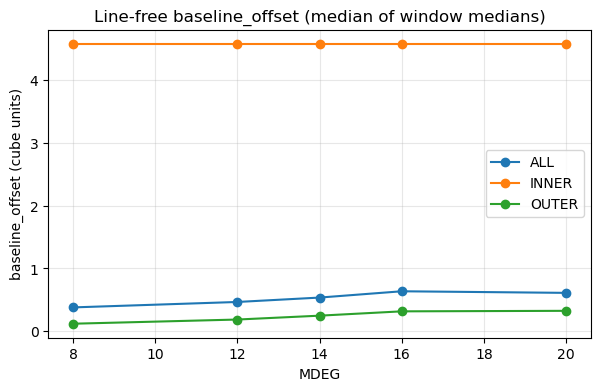

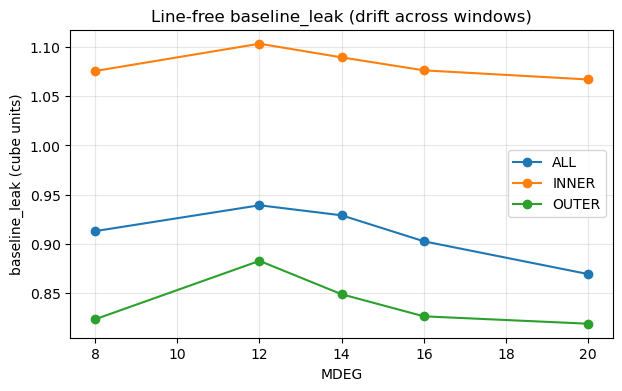

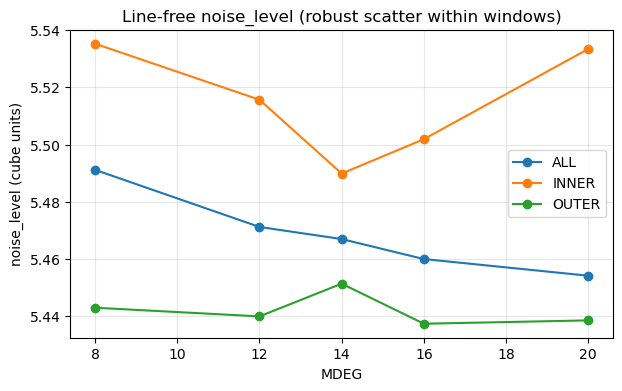

In [8]:
# ============================
# Cell 6: SUMMARIZE + PLOT LINE-FREE METRICS
# ============================
# We summarize each metric by median (p50) and spread (p16,p84).
# Then plot medians vs MDEG for ALL/INNER/OUTER to see robustness.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def summarize_metric(df, metric):
    g = df.groupby(["set", "mdeg"])[metric]
    out = pd.DataFrame({
        "p16": g.quantile(0.16),
        "p50": g.median(),
        "p84": g.quantile(0.84),
        "N": g.count()
    }).reset_index()
    return out

sum_offset = summarize_metric(df_linefree, "baseline_offset")
sum_leak   = summarize_metric(df_linefree, "baseline_leak")
sum_noise  = summarize_metric(df_linefree, "noise_level")

display(sum_offset)
display(sum_leak)
display(sum_noise)

# Plot medians vs MDEG for each set
def plot_metric(summary_df, title, ylabel):
    plt.figure(figsize=(7,4))
    for s in ["ALL", "INNER", "OUTER"]:
        sub = summary_df[summary_df["set"] == s].sort_values("mdeg")
        plt.plot(sub["mdeg"], sub["p50"], marker="o", label=s)
    plt.xlabel("MDEG")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

plot_metric(sum_offset, "Line-free baseline_offset (median of window medians)", "baseline_offset (cube units)")
plot_metric(sum_leak,   "Line-free baseline_leak (drift across windows)", "baseline_leak (cube units)")
plot_metric(sum_noise,  "Line-free noise_level (robust scatter within windows)", "noise_level (cube units)")


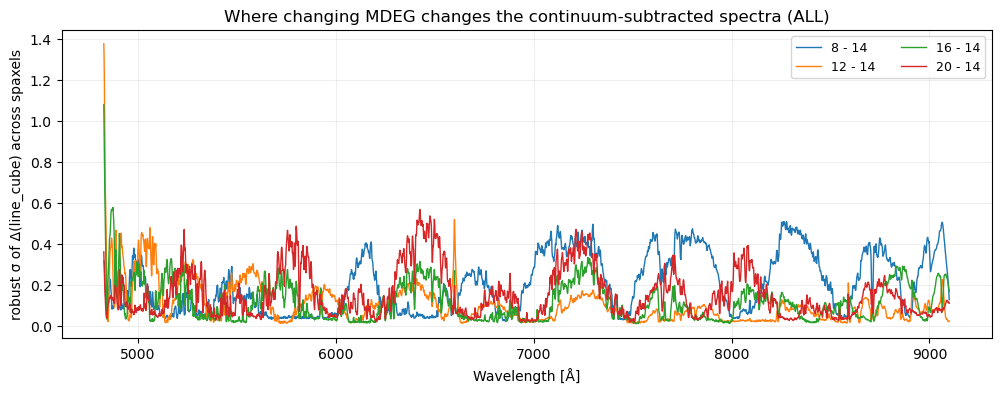

In [15]:
# ============================
# Cell 7: STABILITY FINGERPRINT (Δ spectra vs wavelength)
# ============================
# For each wavelength bin, compute robust sigma across spaxels of:
#   ΔS(λ) = S_MDEG(λ) - S_REF(λ)
# This tells you WHERE in wavelength the subtraction changes when you change MDEG.
#
# We'll do this for ALL spaxels and INNER spaxels (most important scientifically).

import numpy as np
import matplotlib.pyplot as plt

def robust_sigma_across_spaxels_at_each_lambda(D):
    """
    D: (nwave, Nspax) differences
    Return: (nwave,) robust sigma across spaxels at each wavelength.
    """
    med = np.nanmedian(D, axis=1)
    mad = np.nanmedian(np.abs(D - med[:, None]), axis=1)
    return 1.4826 * mad

def plot_delta_fingerprint(xs, ys, label):
    Sref = get_S(REF_MDEG, xs, ys)

    plt.figure(figsize=(12,4))
    for mdeg in sorted(run_ids):
        if mdeg == REF_MDEG:
            continue
        S = get_S(mdeg, xs, ys)
        D = S - Sref
        sig = robust_sigma_across_spaxels_at_each_lambda(D)
        plt.plot(wave_sel, sig, lw=1, label=f"{mdeg} - {REF_MDEG}")

    plt.xlabel("Wavelength [Å]")
    plt.ylabel("robust σ of Δ(line_cube) across spaxels")
    plt.title(f"Where changing MDEG changes the continuum-subtracted spectra ({label})")
    plt.legend(ncol=2, fontsize=9)
    plt.grid(alpha=0.2)
    plt.show()

plot_delta_fingerprint(xs_all, ys_all, "ALL")
# plot_delta_fingerprint(xs_in,  ys_in,  "INNER")


In [10]:
# ============================
# Cell 8: BASELINE-SUBTRACTED LINE FLUXES + STABILITY
# ============================
# We compute, for each spaxel:
#   base = median(S in sidebands)
#   F    = sum( S(line_window) - base ) * dw
#
# Then for each MDEG, compare ΔF/F relative to REF_MDEG for "good" spaxels
# (we enforce a signal cut based on |F_ref| percentile).
#
# We also compute an approximate SNR proxy:
#   snr ~ F / (noise_level_local * sqrt(Npix_line) * dw)
# where noise_level_local is robust sigma in the sidebands.

import numpy as np
import pandas as pd

def compute_line_fluxes_for_set(xs, ys, label):
    """
    Return a long-form dataframe with columns:
      set, mdeg, x, y, F_<line>, snr_<line>
    """
    N = xs.size
    out_rows = []

    # Pre-extract S for each MDEG once (faster)
    S_by_mdeg = {mdeg: get_S(mdeg, xs, ys) for mdeg in sorted(run_ids)}

    for mdeg, S in S_by_mdeg.items():
        rec = {
            "set": np.full(N, label),
            "mdeg": np.full(N, mdeg),
            "x": xs.copy(),
            "y": ys.copy(),
        }

        for lname in line_defs.keys():
            lm = line_masks[lname]
            slm, srm = side_masks[lname]
            line_part = S[lm, :]              # (nlinepix, N)
            side_part = np.vstack([S[slm, :], S[srm, :]])  # (nsidepix, N)

            base = np.nanmedian(side_part, axis=0)

            F = np.nansum(line_part - base[None, :], axis=0) * dw

            # noise_level_local from sidebands (robust sigma within sideband samples)
            # (This is more line-local than global noise_level.)
            nl = robust_sigma_mad_2d(side_part)

            nlinepix = lm.sum()
            snr = F / (nl * np.sqrt(max(nlinepix, 1)) * dw)

            rec[f"F_{lname}"] = F
            rec[f"SNR_{lname}"] = snr

        out_rows.append(pd.DataFrame(rec))

    return pd.concat(out_rows, ignore_index=True)

df_flux_all = compute_line_fluxes_for_set(xs_all, ys_all, "ALL")
df_flux_in  = compute_line_fluxes_for_set(xs_in,  ys_in,  "INNER")

df_flux = pd.concat([df_flux_all, df_flux_in], ignore_index=True)
df_flux.head()


/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_29328/254886537.py:43: RuntimeWarning: All-NaN slice encountered
  base = np.nanmedian(side_part, axis=0)
/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_29328/181408856.py:17: RuntimeWarning: All-NaN slice encountered
  med = np.nanmedian(A, axis=0)
/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_29328/181408856.py:18: RuntimeWarning: All-NaN slice encountered
  mad = np.nanmedian(np.abs(A - med[None, :]), axis=0)


,set,mdeg,x,y,F_Hb,SNR_Hb,F_OIII5007,SNR_OIII5007,F_Ha,SNR_Ha,...,F_SII6716,SNR_SII6716,F_SII6731,SNR_SII6731,F_ArIII7136,SNR_ArIII7136,F_OII7325,SNR_OII7325,F_SIII9069,SNR_SIII9069
0,ALL,8,167,286,27.537216,0.706918,-63.008347,-1.843281,-76.426498,-2.683587,...,9.455672,0.578439,-30.498161,-1.285031,11.654024,0.633633,-73.927513,-3.376295,-56.633907,-1.518131
1,ALL,8,231,172,-37.648331,-0.595190,17.010527,0.423303,6.074443,0.248737,...,-15.413226,-2.072020,-19.902609,-0.652572,13.506385,0.606481,32.214272,1.501332,-34.128250,-1.665201
2,ALL,8,76,175,-28.948578,-0.932268,-6.398002,-0.381362,7.491154,0.468172,...,-7.907767,-1.361857,1.399187,0.124943,-6.445890,-0.645157,1.620650,0.105786,-39.367035,-2.302309
3,ALL,8,284,93,-19.905251,-0.589900,-39.080849,-1.402378,1.252664,0.055247,...,23.068886,1.562418,-36.564602,-3.179348,9.606211,0.479421,-27.964249,-1.023054,-30.348701,-0.839874
4,ALL,8,235,86,35.758148,0.779701,-20.648764,-0.973570,35.300865,2.245165,...,-3.220503,-0.244721,3.695060,0.192621,-22.720449,-1.625493,-7.923400,-0.346062,-19.060543,-0.921547


In [11]:
# ============================
# Cell 9: LINE FLUX + RATIO STABILITY VS REF_MDEG
# ============================
# We compute, for each set (ALL/INNER) and each line:
#   ΔF/Fref (percentiles)
# and for key ratios:
#   Δlog10(ratio) = log10(ratio_mdeg) - log10(ratio_ref)
#
# Ratios we check:
#   - Balmer decrement: Ha/Hb
#   - O3: [OIII]/Hb
#   - N2: [NII6583]/Ha
#   - S2: ([SII6716]+[SII6731]) / Ha

import numpy as np
import pandas as pd

def stability_table_flux(df_flux, set_name, flux_name, signal_pctl=30):
    """
    Build ΔF/Fref quantiles across spaxels for each MDEG vs REF_MDEG.
    We apply a signal cut using |F_ref| percentile among finite values.
    """
    wide = df_flux[df_flux["set"] == set_name].pivot_table(
        index=["y","x"], columns="mdeg", values=flux_name, aggfunc="median"
    )
    if REF_MDEG not in wide.columns:
        raise RuntimeError(f"REF_MDEG={REF_MDEG} missing in wide table for {flux_name}")

    ref = wide[REF_MDEG]
    ok_ref = np.isfinite(ref)
    thr = np.nanpercentile(np.abs(ref[ok_ref]), signal_pctl)
    ok_ref = ok_ref & (np.abs(ref) > thr)

    rows=[]
    for mdeg in sorted(run_ids):
        if mdeg == REF_MDEG:
            continue
        cur = wide.get(mdeg, None)
        if cur is None:
            continue
        ok = ok_ref & np.isfinite(cur) & (ref != 0)
        dfrac = (cur[ok] - ref[ok]) / ref[ok]
        p16, p50, p84 = np.nanpercentile(dfrac, [16,50,84])
        rows.append({"set": set_name, "mdeg": mdeg, "metric": flux_name,
                     "p16": p16, "p50": p50, "p84": p84, "N": int(ok.sum())})
    return pd.DataFrame(rows)

def build_ratios(df_flux, set_name):
    """
    Build per-spaxel ratios for each MDEG:
      Ha/Hb, OIII/Hb, NII/Ha, SII/Ha
    Return wide tables for each ratio keyed by mdeg.
    """
    sub = df_flux[df_flux["set"] == set_name].copy()

    # Define needed flux columns
    F_Ha = sub["F_Ha"]
    F_Hb = sub["F_Hb"]
    F_O3 = sub["F_OIII5007"]
    F_N2 = sub["F_NII6583"]
    F_S2 = sub["F_SII6716"] + sub["F_SII6731"]

    # Ratios (use np.where to avoid division by zero)
    sub["R_HaHb"] = np.where(F_Hb != 0, F_Ha / F_Hb, np.nan)
    sub["R_O3Hb"] = np.where(F_Hb != 0, F_O3 / F_Hb, np.nan)
    sub["R_N2Ha"] = np.where(F_Ha != 0, F_N2 / F_Ha, np.nan)
    sub["R_S2Ha"] = np.where(F_Ha != 0, F_S2 / F_Ha, np.nan)

    # Pivot to wide by mdeg
    ratios = {}
    for rname in ["R_HaHb","R_O3Hb","R_N2Ha","R_S2Ha"]:
        ratios[rname] = sub.pivot_table(index=["y","x"], columns="mdeg", values=rname, aggfunc="median")
    return ratios

def stability_table_logratio(rwide, rname, signal_pctl=30):
    """
    rwide: wide ratio table (index spaxel, columns mdeg)
    Compute Δlog10(ratio) quantiles vs REF_MDEG for spaxels with strong ratio definition.
    """
    ref = rwide[REF_MDEG]
    ok_ref = np.isfinite(ref) & (ref > 0)

    # signal cut: use magnitude of numerator/denominator indirectly not available; we cut on ratio itself loosely
    thr = np.nanpercentile(np.abs(np.log10(ref[ok_ref])), signal_pctl) if ok_ref.sum() else 0.0
    ok_ref = ok_ref  # keep simple; you can strengthen later using SNR cuts

    rows=[]
    for mdeg in sorted(run_ids):
        if mdeg == REF_MDEG:
            continue
        cur = rwide.get(mdeg, None)
        if cur is None:
            continue
        ok = ok_ref & np.isfinite(cur) & (cur > 0)
        dlog = np.log10(cur[ok]) - np.log10(ref[ok])
        p16, p50, p84 = np.nanpercentile(dlog, [16,50,84])
        rows.append({"mdeg": mdeg, "metric": rname, "p16": p16, "p50": p50, "p84": p84, "N": int(ok.sum())})
    return pd.DataFrame(rows)

# ---- Flux stability tables (ALL and INNER)
flux_metrics = ["F_Hb","F_OIII5007","F_Ha","F_NII6583","F_SII6716","F_SII6731","F_ArIII7136","F_OII7325","F_SIII9069"]

stab_flux_all = pd.concat([stability_table_flux(df_flux, "ALL",  fm) for fm in flux_metrics], ignore_index=True)
stab_flux_in  = pd.concat([stability_table_flux(df_flux, "INNER", fm) for fm in flux_metrics], ignore_index=True)

display(stab_flux_all)
display(stab_flux_in)

# ---- Ratio stability tables (ALL and INNER)
rat_all = build_ratios(df_flux, "ALL")
rat_in  = build_ratios(df_flux, "INNER")

stab_rat_all = pd.concat([stability_table_logratio(rat_all[r], r) for r in rat_all], ignore_index=True)
stab_rat_in  = pd.concat([stability_table_logratio(rat_in[r],  r) for r in rat_in], ignore_index=True)

display(stab_rat_all)
display(stab_rat_in)


,set,mdeg,metric,p16,p50,p84,N
0,ALL,8,F_Hb,-0.188212,0.000000,0.082227,560
1,ALL,12,F_Hb,-0.334502,0.000000,0.168484,560
2,ALL,16,F_Hb,-0.360990,0.000000,0.118199,560
3,ALL,20,F_Hb,-0.231262,0.000000,0.067969,560
4,ALL,8,F_OIII5007,-0.010967,0.000000,0.010921,560
5,ALL,12,F_OIII5007,-0.010937,0.000000,0.011706,560
6,ALL,16,F_OIII5007,-0.008588,0.000000,0.011988,560
7,ALL,20,F_OIII5007,-0.014464,0.000000,0.016950,560
8,ALL,8,F_Ha,-0.028864,0.000000,0.015744,560
9,ALL,12,F_Ha,-0.025607,0.000000,0.013671,560


,set,mdeg,metric,p16,p50,p84,N
0,INNER,8,F_Hb,-0.136315,0.0,0.000000,420
1,INNER,12,F_Hb,-0.308188,0.0,0.000000,420
2,INNER,16,F_Hb,-0.338248,0.0,-0.000000,420
3,INNER,20,F_Hb,-0.157456,0.0,0.000000,420
4,INNER,8,F_OIII5007,-0.007268,0.0,0.003450,420
5,INNER,12,F_OIII5007,-0.007770,0.0,0.004894,420
6,INNER,16,F_OIII5007,-0.003870,-0.0,0.004519,420
7,INNER,20,F_OIII5007,-0.011685,0.0,0.006904,420
8,INNER,8,F_Ha,-0.009652,0.0,0.002773,420
9,INNER,12,F_Ha,-0.006041,0.0,0.005532,420


,mdeg,metric,p16,p50,p84,N
0,8,R_HaHb,-0.056578,0.0,0.075699,406
1,12,R_HaHb,-0.105558,0.0,0.160410,392
2,16,R_HaHb,-0.057209,0.0,0.197630,395
3,20,R_HaHb,-0.066885,0.0,0.100363,408
4,8,R_O3Hb,-0.044632,0.0,0.114229,398
5,12,R_O3Hb,-0.063585,0.0,0.205446,379
6,16,R_O3Hb,-0.050060,0.0,0.195736,379
7,20,R_O3Hb,-0.033111,0.0,0.150618,395
8,8,R_N2Ha,-0.055723,0.0,0.022479,257
9,12,R_N2Ha,-0.048920,0.0,0.021019,255


,mdeg,metric,p16,p50,p84,N
0,8,R_HaHb,0.000000,0.0,0.041304,303
1,12,R_HaHb,-0.010767,0.0,0.090646,298
2,16,R_HaHb,0.000000,0.0,0.072237,292
3,20,R_HaHb,0.000000,0.0,0.044813,298
4,8,R_O3Hb,0.000000,0.0,0.084072,306
5,12,R_O3Hb,0.000000,0.0,0.123736,293
6,16,R_O3Hb,0.000000,0.0,0.155400,294
7,20,R_O3Hb,0.000000,0.0,0.077779,297
8,8,R_N2Ha,-0.024429,0.0,0.000000,185
9,12,R_N2Ha,-0.030885,0.0,0.000000,185


In [12]:
# ============================
# Cell 10: SCORECARD (INNER) — DECISION TABLE
# ============================
# Philosophy:
# - Line-free metrics ensure subtraction is "well-behaved" where it should be 0:
#     baseline_offset ~ 0, baseline_leak small, noise_level reasonable.
# - Line-window metrics ensure emission-line science is stable:
#     small |ΔF/F| and small |Δlog ratios| vs fiducial.
#
# We construct a scalar score by min-max normalizing each metric across MDEGs and summing with weights.
# Lower score = better compromise.

import numpy as np
import pandas as pd

# --- Grab INNER medians for line-free metrics
def p50_set(df_linefree, set_name, col):
    return df_linefree[df_linefree["set"] == set_name].groupby("mdeg")[col].median()

core = pd.DataFrame({
    "baseline_offset_p50": p50_set(df_linefree, "INNER", "baseline_offset"),
    "baseline_leak_p50":   p50_set(df_linefree, "INNER", "baseline_leak"),
    "noise_level_p50":     p50_set(df_linefree, "INNER", "noise_level"),
})

# --- Build a single "line flux stability" number:
# median over lines of median(|ΔF/Fref|) (exclude REF which is 0 by definition)
def line_flux_stability_scalar(stab_flux_df, set_name):
    sub = stab_flux_df[stab_flux_df["set"] == set_name].copy()
    # We take the median absolute p50 across many lines (robust scalar)
    # p50 in stab table is median ΔF/F; take abs then median across lines.
    vals = sub.groupby(["mdeg"])["p50"].apply(lambda v: np.nanmedian(np.abs(v)))
    return vals

lfstab = line_flux_stability_scalar(pd.concat([stab_flux_all, stab_flux_in], ignore_index=True), "INNER")
core["line_flux_stab_abs_p50"] = lfstab

# Force REF value to 0 for stability scalars if missing
core.loc[REF_MDEG, "line_flux_stab_abs_p50"] = 0.0

# --- Build a ratio stability scalar: median over ratios of median(|Δlog|).
def ratio_stability_scalar(stab_rat_df):
    vals = stab_rat_df.groupby("mdeg")["p50"].apply(lambda v: np.nanmedian(np.abs(v)))
    return vals

rstab = ratio_stability_scalar(stab_rat_in)
core["ratio_stab_abs_p50"] = rstab
core.loc[REF_MDEG, "ratio_stab_abs_p50"] = 0.0

# --- Normalize and score (weights can be tuned)
# Note: baseline_offset is signed; we score its absolute value.
core["abs_baseline_offset_p50"] = np.abs(core["baseline_offset_p50"])

metrics_for_score = [
    "abs_baseline_offset_p50",
    "baseline_leak_p50",
    "noise_level_p50",
    "line_flux_stab_abs_p50",
    "ratio_stab_abs_p50",
]

# Min-max normalize (protect against zero range)
norm = core[metrics_for_score].copy()
for c in metrics_for_score:
    cmin, cmax = np.nanmin(norm[c]), np.nanmax(norm[c])
    if np.isfinite(cmin) and np.isfinite(cmax) and (cmax > cmin):
        norm[c] = (norm[c] - cmin) / (cmax - cmin)
    else:
        norm[c] = 0.0

weights = {
    "abs_baseline_offset_p50": 1.0,
    "baseline_leak_p50":       1.0,
    "noise_level_p50":         1.0,
    "line_flux_stab_abs_p50":  2.0,  # emphasize line science
    "ratio_stab_abs_p50":      2.0,  # emphasize ratios (metallicity/extinction)
}

core["score"] = 0.0
for c in metrics_for_score:
    core["score"] += weights[c] * norm[c]

core = core.sort_values("score")
display(core)
print("\nBest (lowest score) MDEG according to INNER-weighted scorecard:", int(core.index[0]))


,baseline_offset_p50,baseline_leak_p50,noise_level_p50,line_flux_stab_abs_p50,ratio_stab_abs_p50,abs_baseline_offset_p50,score
mdeg,,,,,,,
16,4.574381,1.076323,5.501892,0.0,0.0,4.574381,0.520341
14,4.574381,1.089487,5.489878,0.0,0.0,4.574381,0.617814
20,4.574381,1.067041,5.533404,0.0,0.0,4.574381,0.959560
8,4.574381,1.075649,5.535239,0.0,0.0,4.574381,1.236927
12,4.574381,1.103372,5.515667,0.0,0.0,4.574381,1.568533



Best (lowest score) MDEG according to INNER-weighted scorecard: 16


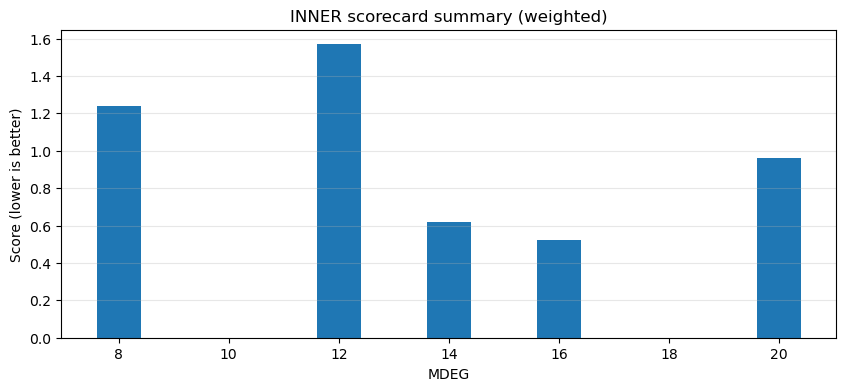

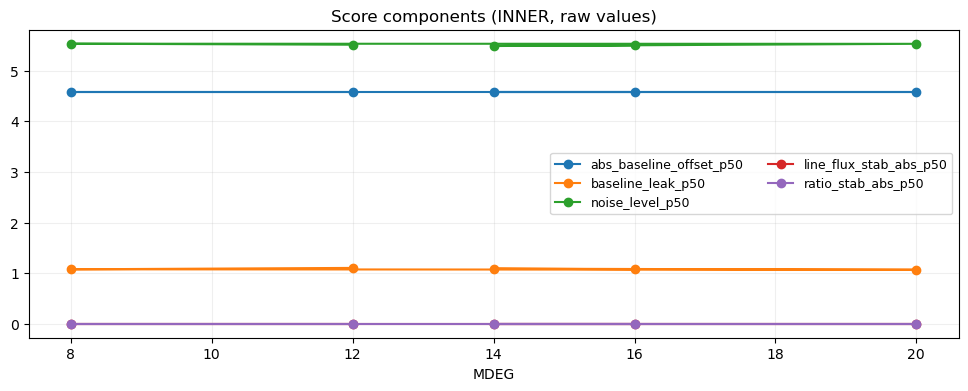

In [13]:
# ============================
# Cell 11: VISUALIZE SCORE COMPONENTS (INNER)
# ============================
# Purpose:
# - Make it easy to explain to Luca why one MDEG is preferred.
# - Show which term drives the score (baseline drift? line ratio stability?).

import matplotlib.pyplot as plt
import numpy as np

mdegs = core.index.values.astype(int)

plt.figure(figsize=(10,4))
plt.bar(mdegs, core["score"].values)
plt.xlabel("MDEG")
plt.ylabel("Score (lower is better)")
plt.title("INNER scorecard summary (weighted)")
plt.grid(axis="y", alpha=0.3)
plt.show()

# Show each component (raw, not normalized)
cols_show = ["abs_baseline_offset_p50","baseline_leak_p50","noise_level_p50","line_flux_stab_abs_p50","ratio_stab_abs_p50"]
plt.figure(figsize=(12,4))
for c in cols_show:
    plt.plot(mdegs, core[c].values, marker="o", label=c)
plt.xlabel("MDEG")
plt.title("Score components (INNER, raw values)")
plt.legend(ncol=2, fontsize=9)
plt.grid(alpha=0.2)
plt.show()


,baseline_offset_p50,baseline_leak_p50,noise_level_p50,abs_baseline_offset_p50,score_linefree
mdeg,,,,,
16,4.574381,1.076323,5.501892,4.574381,0.520341
14,4.574381,1.089487,5.489878,4.574381,0.617814
20,4.574381,1.067041,5.533404,4.574381,0.959560
8,4.574381,1.075649,5.535239,4.574381,1.236927
12,4.574381,1.103372,5.515667,4.574381,1.568533



Best (lowest score) MDEG using LINE-FREE ONLY: 16


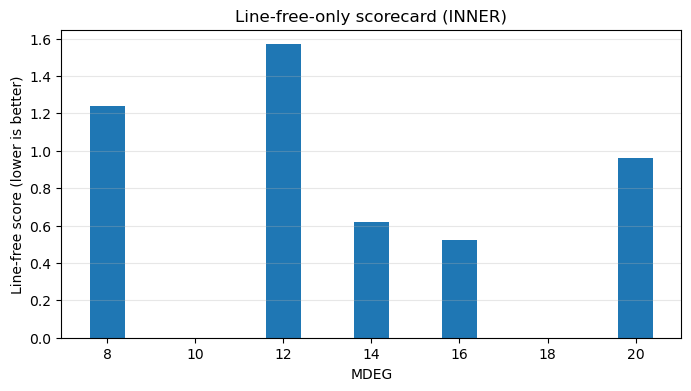

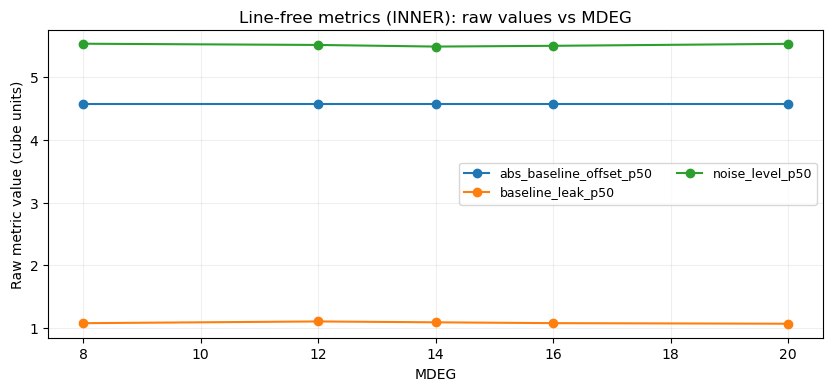

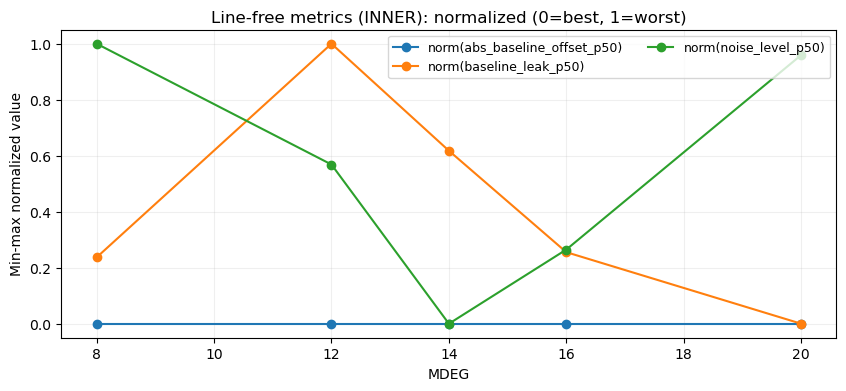

In [14]:
# ============================
# Cell 10 (LINE-FREE ONLY): SCORECARD (INNER) + VISUALIZATION
# ============================
# Goal:
# - Decide which MDEG best balances "good behavior" in line-free windows ONLY.
#
# What we care about (line-free):
# 1) baseline_offset ~ 0   : overall residual baseline offset (bias), sign matters but scoring uses abs().
# 2) baseline_leak small   : drift/tilt/curvature across windows (robust scatter of window medians).
# 3) noise_level reasonable: robust scatter within windows (MAD sigma), then median across windows.
#
# Score definition:
# - For each metric, min-max normalize across MDEGs:
#       norm = (x - min) / (max - min)
#   so best has norm=0 and worst has norm=1 (for "lower is better" metrics).
# - Weighted sum:
#       score = Σ w_i * norm_i
#   Lower score = better compromise.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Helper: median per MDEG for a given set and column
def p50_set(df_linefree, set_name, col):
    return df_linefree[df_linefree["set"] == set_name].groupby("mdeg")[col].median()

# --- Build core table (INNER only)
core = pd.DataFrame({
    "baseline_offset_p50": p50_set(df_linefree, "INNER", "baseline_offset"),
    "baseline_leak_p50":   p50_set(df_linefree, "INNER", "baseline_leak"),
    "noise_level_p50":     p50_set(df_linefree, "INNER", "noise_level"),
}).sort_index()

# Use abs(offset) for scoring: we care about how close to 0 (bias magnitude), not sign.
core["abs_baseline_offset_p50"] = np.abs(core["baseline_offset_p50"])

# Metrics used for line-free-only score
metrics = ["abs_baseline_offset_p50", "baseline_leak_p50", "noise_level_p50"]

# --- Min-max normalization (protect against zero range)
norm = core[metrics].copy()
for c in metrics:
    cmin, cmax = np.nanmin(norm[c].values), np.nanmax(norm[c].values)
    if np.isfinite(cmin) and np.isfinite(cmax) and (cmax > cmin):
        norm[c] = (norm[c] - cmin) / (cmax - cmin)
    else:
        # If the metric does not vary with MDEG, it provides no discriminatory power.
        norm[c] = 0.0

# --- Weights (tune if you want)
# Typical line-free emphasis:
# - baseline_leak: usually important (drift is dangerous)
# - abs_offset: also important (global bias)
# - noise_level: important but can be skyline-driven (so sometimes slightly lower weight)
weights = {
    "abs_baseline_offset_p50": 1.0,
    "baseline_leak_p50":       1.0,
    "noise_level_p50":         1.0,
}

# --- Score (lower is better)
core["score_linefree"] = 0.0
for c in metrics:
    core["score_linefree"] += weights[c] * norm[c]

# Sort by score (best first)
core_sorted = core.sort_values("score_linefree")
display(core_sorted)

best_mdeg = int(core_sorted.index[0])
print("\nBest (lowest score) MDEG using LINE-FREE ONLY:", best_mdeg)

# ============================
# Visualization A: Score bar plot
# ============================
plt.figure(figsize=(8,4))
plt.bar(core_sorted.index.astype(int), core_sorted["score_linefree"].values)
plt.xlabel("MDEG")
plt.ylabel("Line-free score (lower is better)")
plt.title("Line-free-only scorecard (INNER)")
plt.grid(axis="y", alpha=0.3)
plt.show()

# ============================
# Visualization B: Raw components vs MDEG (so you can see physical scale)
# ============================
plt.figure(figsize=(10,4))
plt.plot(core.index.astype(int), core["abs_baseline_offset_p50"], marker="o", label="abs_baseline_offset_p50")
plt.plot(core.index.astype(int), core["baseline_leak_p50"], marker="o", label="baseline_leak_p50")
plt.plot(core.index.astype(int), core["noise_level_p50"], marker="o", label="noise_level_p50")
plt.xlabel("MDEG")
plt.ylabel("Raw metric value (cube units)")
plt.title("Line-free metrics (INNER): raw values vs MDEG")
plt.legend(ncol=2, fontsize=9)
plt.grid(alpha=0.2)
plt.show()

# ============================
# Visualization C: Normalized components vs MDEG (shows what drives the score)
# ============================
plt.figure(figsize=(10,4))
for c in metrics:
    plt.plot(core.index.astype(int), norm.loc[core.index, c].values, marker="o", label=f"norm({c})")
plt.xlabel("MDEG")
plt.ylabel("Min-max normalized value")
plt.title("Line-free metrics (INNER): normalized (0=best, 1=worst)")
plt.legend(ncol=2, fontsize=9)
plt.grid(alpha=0.2)
plt.show()
